## Import Libraries

In [196]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

## Understand and Clean up Data

In [197]:
d = pd.read_csv('Student_data.csv')
d.head(5)

,Sleep,Study,Practice,Exam
0,7.0,2.0,1.0,65
1,6.0,3.0,2.0,70
2,8.0,1.0,NaN,68
3,5.0,NaN,3.0,60
4,7.0,2.0,2.0,72


In [198]:
d.shape

(10, 4)

In [199]:
d.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Sleep     9 non-null      float64
 1   Study     8 non-null      float64
 2   Practice  9 non-null      float64
 3   Exam      10 non-null     int64  
dtypes: float64(3), int64(1)
memory usage: 452.0 bytes


In [200]:
d.isna().sum()

Sleep       1
Study       2
Practice    1
Exam        0
dtype: int64

In [201]:
d.duplicated().sum()

np.int64(0)

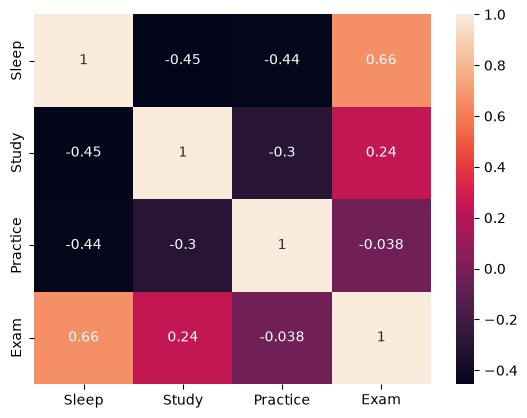

In [202]:
sns.heatmap(d.corr(), annot=True)
plt.show()

In [203]:
d.fillna(d.mean(), inplace=True)
d

,Sleep,Study,Practice,Exam
0,7.000000,2.0,1.000000,65
1,6.000000,3.0,2.000000,70
2,8.000000,1.0,1.888889,68
3,5.000000,2.0,3.000000,60
4,7.000000,2.0,2.000000,72
5,6.000000,3.0,1.000000,66
6,6.666667,2.0,3.000000,67
7,8.000000,2.0,2.000000,75
8,7.000000,2.0,1.000000,64
9,6.000000,1.0,2.000000,63


## Train

In [204]:
x = d[['Sleep', 'Study', 'Practice']]
y = d['Exam']

In [205]:
print(x)
print(y)

      Sleep  Study  Practice
0  7.000000    2.0  1.000000
1  6.000000    3.0  2.000000
2  8.000000    1.0  1.888889
3  5.000000    2.0  3.000000
4  7.000000    2.0  2.000000
5  6.000000    3.0  1.000000
6  6.666667    2.0  3.000000
7  8.000000    2.0  2.000000
8  7.000000    2.0  1.000000
9  6.000000    1.0  2.000000
0    65
1    70
2    68
3    60
4    72
5    66
6    67
7    75
8    64
9    63
Name: Exam, dtype: int64


In [206]:
x_train , x_test , y_train , y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [207]:
lr = LinearRegression()

In [208]:
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[4.6 ,3.2 ,1.39]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Sleep','Study','Practice']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,27.38
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [209]:
pred = lr.predict(x_test)

In [210]:
print(x_test)

   Sleep  Study  Practice
8    7.0    2.0       1.0
1    6.0    3.0       2.0


## Evaluate

In [211]:
print(y_test) # 64 ,    70
print(pred)   # 67.372 , 67.359

8    64
1    70
Name: Exam, dtype: int64
[67.37200737 67.35913501]


In [212]:
print(mean_squared_error(y_test, pred))
print(r2_score(y_test, pred))

9.172300793111033
-0.019144532567892503
